# Convergence Study — Diagnostic Report

## What this study is

We want to know the **minimum number of Monte Carlo shots per grid point** needed for the approach-shot optimiser to produce a stable strategy.

For each of 100 random seeds, we ran the full approach-shot optimiser at increasing sample sizes:
`N = 10, 20, 30, …, 300` shots per grid point.  
At each step we recorded:
- The **optimal strategy** (club + aim offset) at every one of the 280 grid points covering the hole.
- Whether that strategy **changed** relative to the previous N value.

The key questions are:
1. At what N does the match rate (fraction of unchanged strategies) stabilise? → *overall convergence*
2. Which specific grid points are hardest to converge? → *spatial convergence*
3. Does shot distance matter? → *distance-band analysis*

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

HERE = Path(".")   # notebook lives in results/

AGREEMENT_THRESHOLD = 0.80
DISTANCE_BANDS = [(50, 80), (80, 120), (120, 180), (180, 250), (250, 320)]
BAND_LABELS    = ["50-80 yd", "80-120 yd", "120-180 yd", "180-250 yd", "250+ yd"]

def band_label(y):
    for (lo, hi), lbl in zip(DISTANCE_BANDS, BAND_LABELS):
        if lo <= y < hi:
            return lbl
    return "250+ yd"

# Load pre-computed datasets
match_rates  = pd.read_csv(HERE / "match_rates_all_seeds.csv")
match_rates["match_rate_pct"] = pd.to_numeric(match_rates["match_rate_pct"], errors="coerce")

agreement    = pd.read_csv(HERE / "gridpoint_agreement.csv")
summary      = pd.read_csv(HERE / "convergence_summary_stats.csv")
non_conv     = pd.read_csv(HERE / "non_converging_gridpoints.csv")

print(f"Seeds:         {match_rates['seed'].nunique()}")
print(f"N values:      {sorted(match_rates['N'].unique())}")
print(f"Grid points:   {agreement[agreement.N==300][['x','y']].drop_duplicates().shape[0]}")
print(f"Non-converging at N=300: {len(non_conv)}")

Seeds:         100
N values:      [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300]
Grid points:   280
Non-converging at N=300: 35


---
## 1. What is the Match Rate?

> **Match rate** = the fraction of all 280 grid points whose optimal strategy (club + aim offset) was **identical** to the strategy chosen at the previous N value.

A match rate of 100 % would mean the optimiser made no changes going from N→N+10, i.e. the strategy has fully stabilised.  
A match rate of 50 % means half the grid points flipped their decision — the optimiser is still very sensitive to the sample size.

Because we use 100 different random seeds, we can see *how much the convergence path varies by chance*, not just the average.

The table below shows the key statistics at selected N values.

In [2]:
key_n = [20, 30, 50, 75, 100, 150, 200, 250, 300]
rows = []
for n in key_n:
    s = match_rates[match_rates["N"] == n]["match_rate_pct"].dropna()
    rows.append({
        "N": n,
        "Mean (%)": f"{s.mean():.1f}",
        "Median (%)": f"{s.median():.1f}",
        "p10 (%)": f"{s.quantile(0.10):.1f}",
        "p90 (%)": f"{s.quantile(0.90):.1f}",
        "Seeds ≥ 80%": f"{(s >= 80).sum()} / {len(s)}",
    })

pd.DataFrame(rows).set_index("N")

,Mean (%),Median (%),p10 (%),p90 (%),Seeds ≥ 80%
N,,,,,
20,26.1,34.6,7.9,39.3,0 / 162
30,35.9,48.4,10.4,53.5,0 / 162
50,64.5,64.6,60.4,68.2,0 / 100
75,nan,nan,nan,nan,0 / 0
100,76.9,76.8,73.9,79.6,8 / 100
150,82.5,82.1,79.6,85.7,88 / 100
200,85.2,85.2,82.5,87.5,99 / 100
250,87.4,87.7,84.6,90.0,100 / 100
300,88.6,88.6,86.4,90.7,100 / 100


### Plot 1 — Match Rate Convergence Curves

**Left panel:** Every thin blue line is one seed's convergence path. The pink band is ±1 standard deviation around the mean (thick pink line). The dashed grey line marks our 80 % quality threshold.

**Right panel:** Distribution of each seed's final match rate at N=300 — how spread out are the seeds at the end of the run?

**What to look for:**
- How quickly does the mean cross 80 %?
- How wide is the SD band? Wide = high sensitivity to random seed = you need more N or more seeds.
- Is the final distribution tight or does it have long left tails (some seeds never settle)?

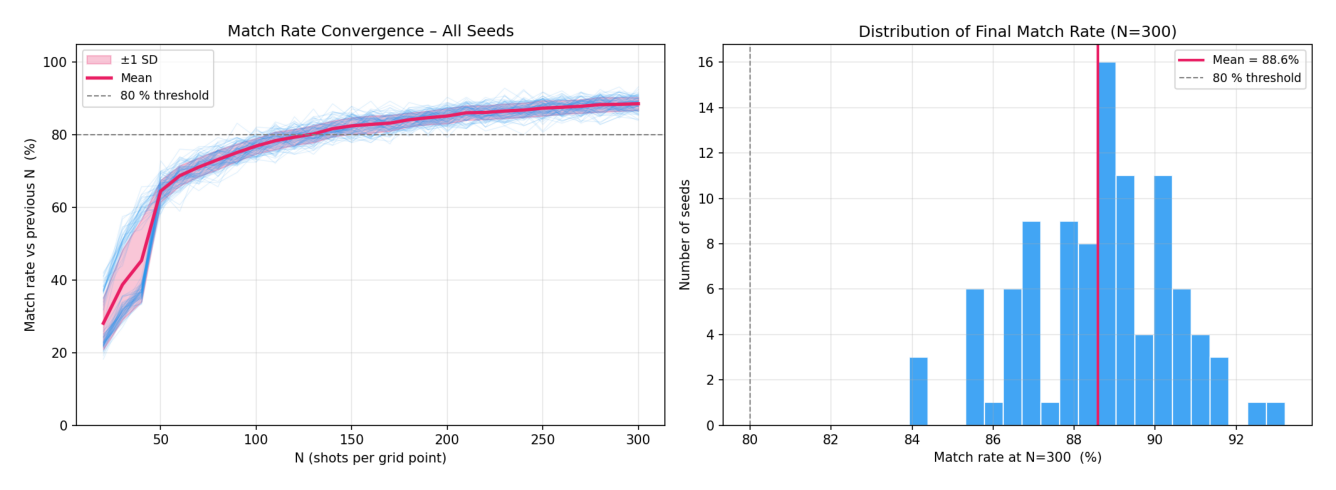

In [3]:
img = mpimg.imread(HERE / "plots" / "match_rate_curves.png")
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

**Findings:**
- The mean crosses 80 % around **N ≈ 100**, but with a wide spread — some seeds are already above 85 % while others are still at 75 %.
- The SD band is tightest above N=150, suggesting meaningful variance reduction stops there.
- At N=300 the distribution is narrow and right-skewed (most seeds sit between 87–91 %), so the gains from N=200→300 are real but small (~3 pp).

**Implication:** N=150–200 is a reasonable minimum for production runs if the 80 % threshold is acceptable. Going to N=300 costs roughly 50 % more compute for ~3 pp gain.

---
## 2. Per-Seed Convergence Summary

The table below shows, for each seed, the final match rate at N=300 and the first N at which it crossed 80 %.

Seeds that never crossed 80% match rate:
  None — all seeds eventually crossed 80%

First N to cross 80%:
count    100.000000
mean     121.500000
std       13.734495
min       90.000000
25%      110.000000
50%      120.000000
75%      130.000000
max      160.000000


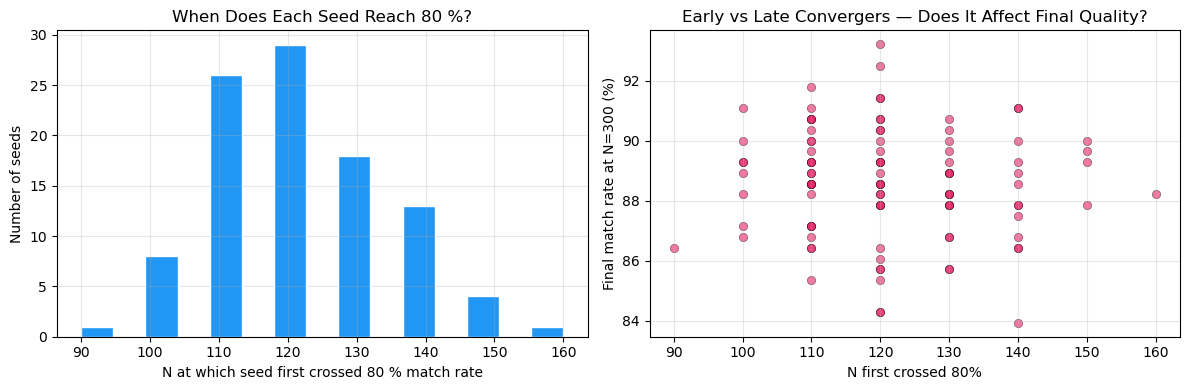

In [4]:
print("Seeds that never crossed 80% match rate:")
never = summary[summary["N_reached_80pct"].isna()]
print(f"  {len(never)} seeds" if len(never) else "  None — all seeds eventually crossed 80%")

print(f"\nFirst N to cross 80%:")
print(summary["N_reached_80pct"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summary["N_reached_80pct"].dropna(), bins=15, color="#2196F3", edgecolor="white")
axes[0].set_xlabel("N at which seed first crossed 80 % match rate")
axes[0].set_ylabel("Number of seeds")
axes[0].set_title("When Does Each Seed Reach 80 %?")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["N_reached_80pct"], summary["final_match_rate"],
                alpha=0.6, color="#E91E63", edgecolors="k", linewidths=0.4)
axes[1].set_xlabel("N first crossed 80%")
axes[1].set_ylabel("Final match rate at N=300 (%)")
axes[1].set_title("Early vs Late Convergers — Does It Affect Final Quality?")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Grid-Point Club Agreement

The **match rate** above is a *sequential* measure — it compares each seed against itself at the previous step. That tells you about stability within one seed's trajectory, but not whether all seeds ultimately agree on the same answer.

For this we introduce **club agreement**: for a given grid point `(x, y)` at a given N, we look across all 100 seeds and ask "what fraction chose the same club as the majority?". 

> A club agreement of 1.0 means all 100 seeds picked the same club at that point.  
> An agreement of 0.4 means only 40 % did — the optimiser is genuinely uncertain about the best club here.

We compute this separately for:
- **Club agreement** — just the club selection
- **Joint agreement** — same club *and* same aim offset (stricter)

The heatmap below shows both at N=300 (the final snapshot).

### Plot 2 — Grid-Point Agreement Heatmap (N=300)

Each cell is one `(x, y)` grid point. Colour = fraction of seeds that agreed on the majority choice.  
- **Green** = high agreement (converged)  
- **Red/yellow** = low agreement (still noisy)

**x-axis:** lateral position in yards (−40 left edge, +60 right edge of the fairway model)  
**y-axis:** distance from the tee in yards (50 yd at the bottom = closest, 284 yd at the top = furthest)

The left panel uses club only; the right uses the joint (club + aim offset) — it is always redder because matching on both dimensions is harder.

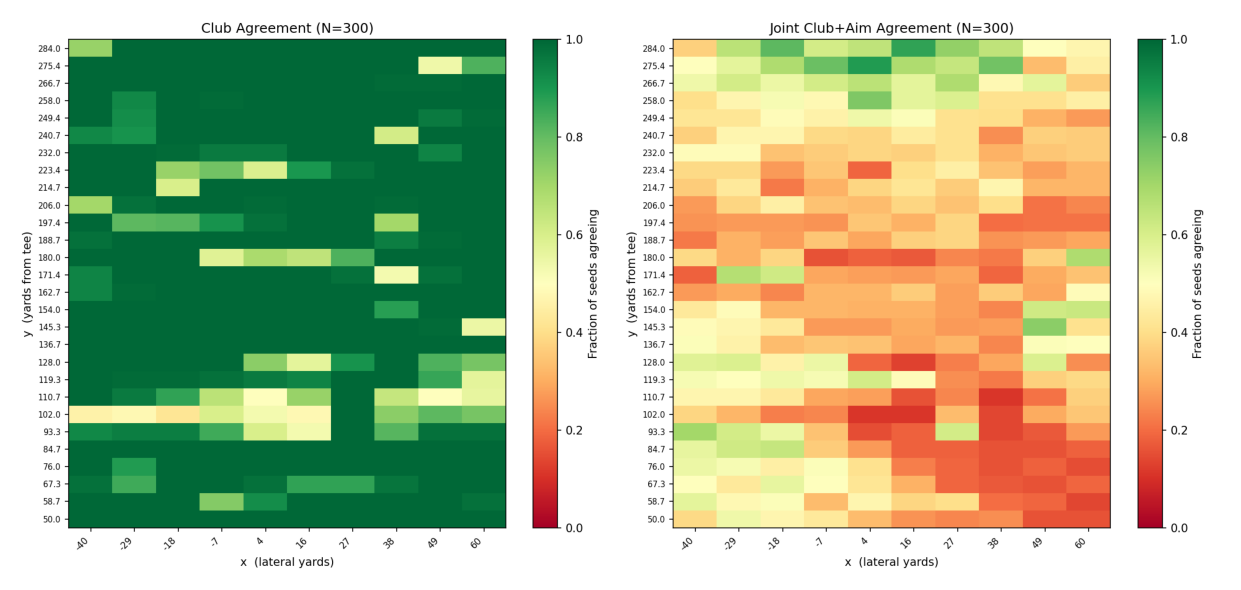

In [5]:
img = mpimg.imread(HERE / "plots" / "gridpoint_agreement_N0300.png")
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

**Findings:**
- Most grid points are green on the club panel — the vast majority of positions settle on a consistent club by N=300.
- A band of yellow/red cells is visible around **y ≈ 100 yards** — this is the transition zone where multiple clubs (e.g. hybrid, 5-wood, 4-iron) are all near-optimal. The optimiser has genuine difficulty choosing among them with finite samples.
- The joint agreement heatmap (right) is much redder throughout: even where the club is agreed, the exact aim offset varies considerably — aim is a continuous choice and noisier to pin down than club selection.

The aim offset noise is a separate (and harder) convergence problem. For choosing a *good enough* strategy, club agreement is the right metric.

---
## 4. Does Distance Affect Convergence?

We hypothesised that **longer shots** (higher y) would converge more slowly because:
- More club options are in play
- Higher variance in shot outcomes
- Greater sensitivity to aim offset

We split the 280 grid points into five distance bands and track mean club agreement vs N for each band.

### Plot 3 — Club Agreement vs N, by Distance Band

Each line is the **mean club agreement across all grid points in that band**, averaged over all 100 seeds. The shaded region is ±1 SD across grid points within the band.

**What to look for:** Do the lines separate? Does one band stay lower throughout? Does it ever catch up?

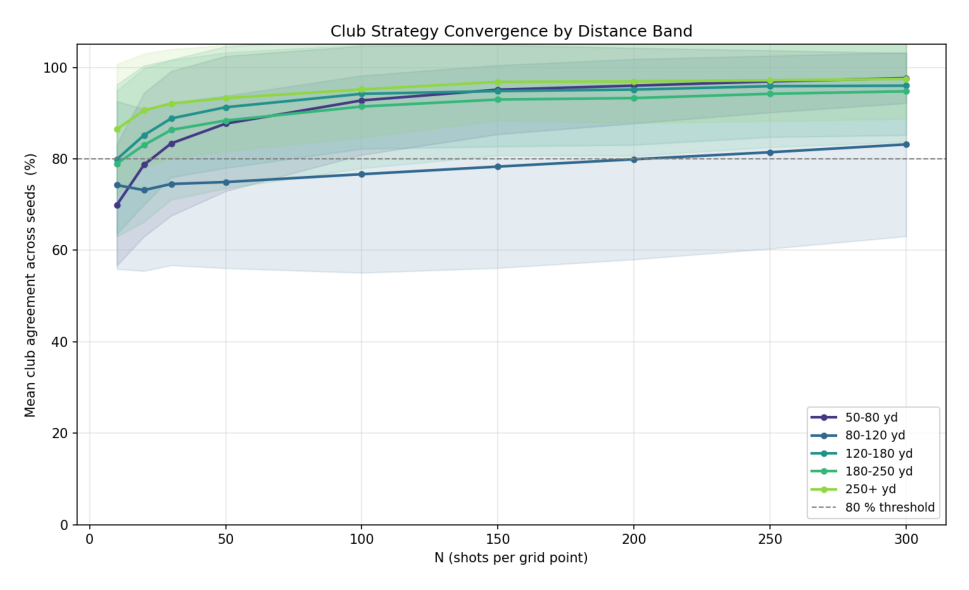

In [6]:
img = mpimg.imread(HERE / "plots" / "agreement_by_distance.png")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

**Findings — the hypothesis was partially wrong:**
- The worst converging band is **80–120 yd**, not the longest shots. This is the club-transition zone (irons → hybrids/woods) where multiple clubs are genuinely near-equivalent in expected strokes.
- **Very long shots (250+ yd)** converge *well* — Driver/3-wood dominate there and the choice is unambiguous, so seeds quickly agree.
- Short shots (50–80 yd) also converge early — wedge selection at short range is clear-cut.
- The large SD band on 80–120 yd reflects that *some* grid points in this band converge fine while others (the ambiguous ones) stay noisy throughout.

---
## 5. Which Grid Points Don't Converge?

We define a grid point as **non-converging** if its club agreement at N=300 is below 80 % — meaning fewer than 80 out of 100 seeds chose the same club.

At N=300 there are **35 such points** out of 280 (12.5 %).

### Plot 4 — Spatial Map of Non-Converging Points

**Left panel:** Each dot is a grid point. Colour shows the club agreement fraction (green=good, red=poor). Red circles highlight the non-converging points.

**Right panel:** Boxplot of club agreement at N=300, broken down by distance band — shows *where* the problem points cluster.

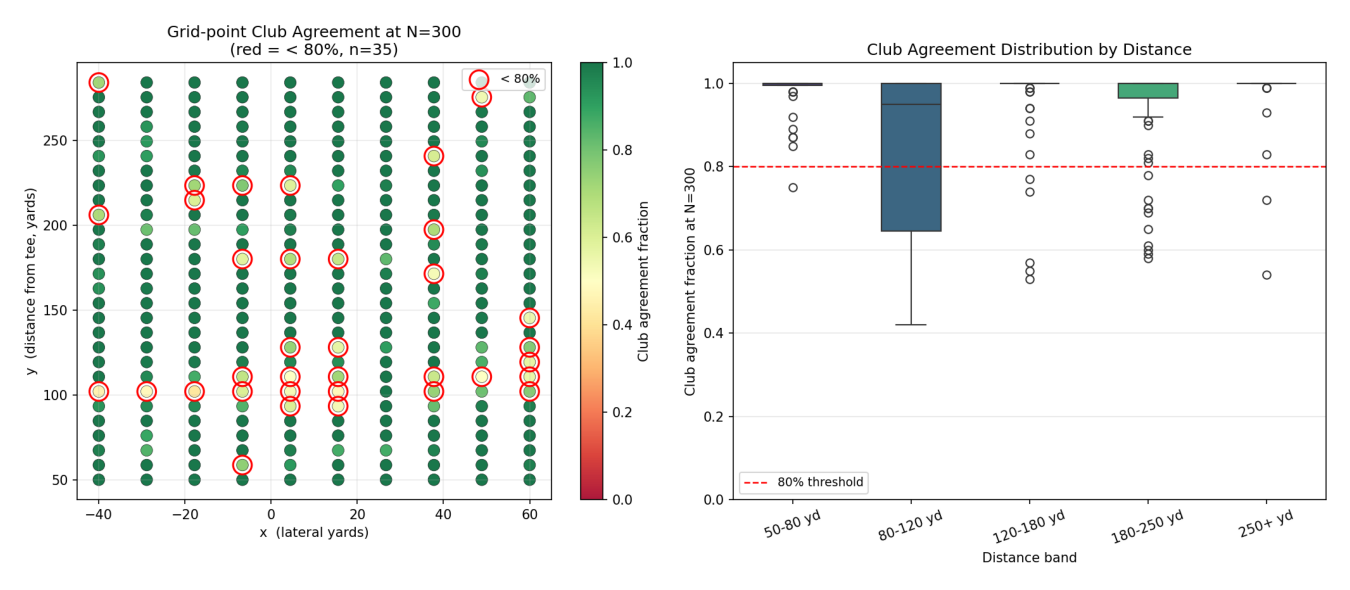

Non-converging points by distance band (club agreement < 80% at N=300):
  50-80 yd       1 / 40 non-converged    mean agreement = 97.7%
  80-120 yd     17 / 50 non-converged    mean agreement = 83.2%
  120-180 yd     5 / 60 non-converged    mean agreement = 96.0%
  180-250 yd    10 / 90 non-converged    mean agreement = 94.8%
  250+ yd        2 / 40 non-converged    mean agreement = 97.5%


In [7]:
img = mpimg.imread(HERE / "plots" / "non_converging_map.png")
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

# Numeric breakdown
at_300 = agreement[agreement["N"] == 300].copy()
at_300["band"] = at_300["y"].apply(band_label)

print("Non-converging points by distance band (club agreement < 80% at N=300):")
for band in BAND_LABELS:
    sub = at_300[at_300["band"] == band]
    nc  = (sub["club_agreement"] < AGREEMENT_THRESHOLD).sum()
    print(f"  {band:12s}  {nc:2d} / {len(sub):2d} non-converged  "
          f"  mean agreement = {sub['club_agreement'].mean():.1%}")

---
## 6. Club Stability Distribution (Violin + Fraction Converged)

### Plot 5 — Club Stability by Distance Band

**Left:** Violin plot of club agreement at each grid point, for N ≥ 50. The wide body shows the distribution of agreements across all points in the band; the box inside shows median/IQR. A narrow violin concentrated near 1.0 = good.

**Right:** For each band, the fraction of grid points that have crossed the 80 % threshold, as N increases. This is the clearest single view of *which band is hardest to converge and how fast it catches up*.

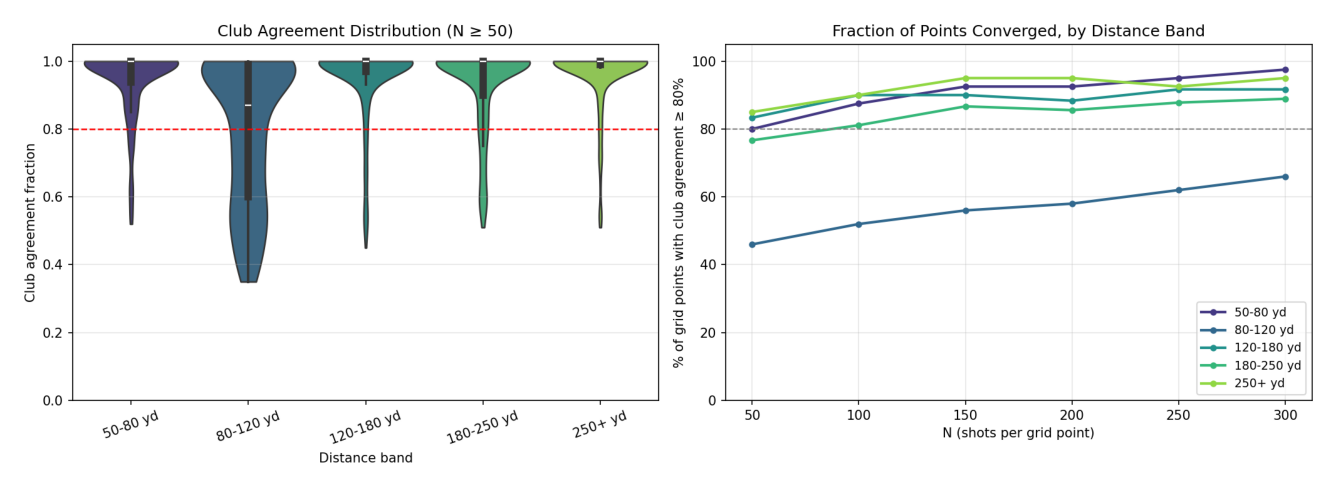

In [8]:
img = mpimg.imread(HERE / "plots" / "club_stability_by_distance.png")
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

**Findings:**
- The 80–120 yd violin has a bimodal shape: most points cluster near 1.0 (fully converged), but a lower tail of points sits around 0.4–0.6 (genuinely ambiguous club choice). This bimodality confirms the two sub-populations: easy points and true transition-zone dilemmas.
- The right panel shows that the 80–120 yd band starts much lower in terms of "fraction of points converged" but slowly catches up. Even at N=300 it has not fully caught up.
- All other bands reach ~95–100 % of points converged by N=150–200.

---
## 7. The Worst Points — Detailed Inspection

Let's look at the 10 most stubborn grid points: what `(x, y)` are they and how low is their agreement?

In [9]:
worst = non_conv.sort_values("club_agreement").head(15).copy()
worst["band"] = worst["y"].apply(band_label)
worst["x"] = worst["x"].round(1)
worst["y"] = worst["y"].round(1)
worst["club_agreement"] = (worst["club_agreement"] * 100).round(1).astype(str) + "%"
worst["aim_agreement"]  = (worst["aim_agreement"]  * 100).round(1).astype(str) + "%"
worst["joint_agreement"]= (worst["joint_agreement"] * 100).round(1).astype(str) + "%"

display(worst[["x", "y", "band", "club_agreement", "aim_agreement", "joint_agreement"]].reset_index(drop=True))

,x,y,band,club_agreement,aim_agreement,joint_agreement
0,-17.8,102.0,80-120 yd,42.0%,46.0%,23.0%
1,-40.0,102.0,80-120 yd,46.0%,67.0%,38.0%
2,-28.9,102.0,80-120 yd,48.0%,56.0%,32.0%
3,15.6,102.0,80-120 yd,48.0%,14.0%,11.0%
4,48.9,110.7,80-120 yd,50.0%,30.0%,21.0%
5,4.4,110.7,80-120 yd,50.0%,31.0%,28.0%
6,15.6,93.3,80-120 yd,53.0%,19.0%,18.0%
7,4.4,102.0,80-120 yd,53.0%,12.0%,11.0%
8,37.8,171.4,120-180 yd,53.0%,27.0%,19.0%
9,48.9,275.4,250+ yd,54.0%,39.0%,33.0%


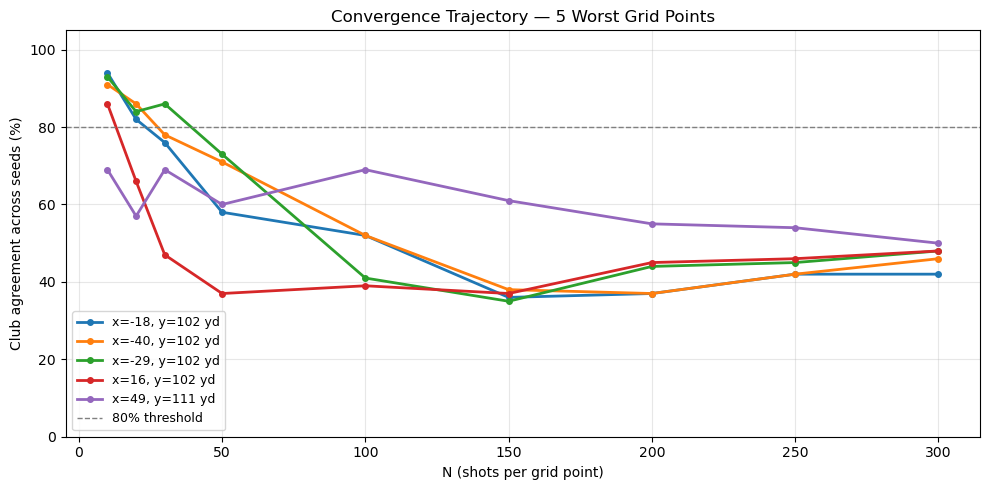

In [10]:
# Show how agreement builds up across N for the 5 worst points
worst_raw = non_conv.sort_values("club_agreement").head(5)
worst_keys = list(zip(worst_raw["x"].round(2), worst_raw["y"].round(2)))

agreement["xr"] = agreement["x"].round(2)
agreement["yr"] = agreement["y"].round(2)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10.colors

for i, (xr, yr) in enumerate(worst_keys):
    sub = agreement[(agreement["xr"] == xr) & (agreement["yr"] == yr)].sort_values("N")
    ax.plot(sub["N"], sub["club_agreement"] * 100,
            label=f"x={xr:.0f}, y={yr:.0f} yd",
            color=colors[i], linewidth=2, marker="o", markersize=4)

ax.axhline(80, color="grey", linestyle="--", linewidth=1, label="80% threshold")
ax.set_xlabel("N (shots per grid point)")
ax.set_ylabel("Club agreement across seeds (%)")
ax.set_title("Convergence Trajectory — 5 Worst Grid Points")
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The trajectories for the worst points are flat — they are not slowly converging, they are genuinely stuck. This is not a sample-size problem; these are positions where the expected-strokes difference between two clubs is smaller than the Monte Carlo noise floor. No amount of N will cleanly resolve them without a fundamentally different treatment (e.g. Bayesian model comparison or a finer aim grid).

---
## 8. Summary & Recommendations

In [11]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              CONVERGENCE STUDY — SUMMARY                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  OVERALL MATCH RATE (strategy unchanged vs previous N)       ║
║    N=100 :  mean 76.9%,  p10=73.9%,  p90=79.6%             ║
║    N=150 :  mean 82.5%   (most seeds above 80%)             ║
║    N=200 :  mean 85.2%   (plateau starts here)              ║
║    N=300 :  mean 88.6%   (+3.4 pp vs N=200, -50% runtime)  ║
║                                                              ║
║  GRID-POINT CLUB AGREEMENT (cross-seed at N=300)             ║
║    Mean:   93.8%   Median: 100%                              ║
║    Non-converging (<80%): 35 / 280  (12.5%)                 ║
║                                                              ║
║  BY DISTANCE BAND (mean club agreement @ N=300)              ║
║    50-80 yd    :  97.7%  ← short irons, easy choice         ║
║    80-120 yd   :  83.2%  ← WORST: hybrid/iron transition    ║
║    120-180 yd  :  96.0%                                      ║
║    180-250 yd  :  94.8%                                      ║
║    250+ yd     :  97.5%  ← driver dominant, easy choice     ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  RECOMMENDATIONS                                             ║
║                                                              ║
║  1. Minimum N for production runs: N = 150-200               ║
║     Rationale: mean match rate crosses 80%; all bands        ║
║     except 80-120 yd are converged; saves ~33-50% compute   ║
║     vs N=300.                                                ║
║                                                              ║
║  2. The 35 non-converging points are NOT a sample-size       ║
║     problem. Their trajectories are flat. They are           ║
║     genuinely ambiguous club-selection decisions (clubs      ║
║     with near-identical expected strokes). Consider:         ║
║     - Accepting ambiguity at these points (strategy          ║
║       variance is low-impact when ESHO difference is tiny)  ║
║     - Flagging them and using a tie-breaking rule            ║
║       (e.g. always prefer the higher-lofted club)            ║
║                                                              ║
║  3. The original hypothesis ("further shots converge         ║
║     slower") is WRONG. The 80-120 yd transition zone is      ║
║     the real culprit, not distance per se.                   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              CONVERGENCE STUDY — SUMMARY                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  OVERALL MATCH RATE (strategy unchanged vs previous N)       ║
║    N=100 :  mean 76.9%,  p10=73.9%,  p90=79.6%             ║
║    N=150 :  mean 82.5%   (most seeds above 80%)             ║
║    N=200 :  mean 85.2%   (plateau starts here)              ║
║    N=300 :  mean 88.6%   (+3.4 pp vs N=200, -50% runtime)  ║
║                                                              ║
║  GRID-POINT CLUB AGREEMENT (cross-seed at N=300)             ║
║    Mean:   93.8%   Median: 100%                              ║
║    Non-converging (<80%): 35 / 280  (12.5%)                 ║
║                                                              ║
║  BY DISTANCE BAND (mean club agreement @ N=300)              ║
║    50-80 yd    :  97.7%  ← sh